In [1]:
# If TensorFlow is not already available in your Colab runtime, uncomment:
# !pip install tensorflow

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATASET_PATH = '/content/drive/MyDrive/AI ML/collab/week7/Copy of Copy of devnagari digit.zip'
IMG_SIZE = 28

In [5]:
import zipfile
import os

zip_file_path = '/content/drive/MyDrive/AI ML/collab/week7/Copy of Copy of devnagari digit.zip'
extraction_path = '/content/drive/MyDrive/AI ML/collab/week7/extracted_digits'

# Create the directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"'{zip_file_path}' extracted to '{extraction_path}' successfully.")

# List contents of the extracted directory to verify
print(f"Contents of '{extraction_path}':")
for root, dirs, files in os.walk(extraction_path):
    level = root.replace(extraction_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f"{subindent}{f}")


Streaming output truncated to the last 5000 lines.
                10301.png
                10302.png
                10303.png
                10304.png
                10306.png
                10307.png
                104017.png
                104018.png
                104019.png
                104021.png
                104023.png
                104024.png
                104025.png
                104026.png
                104027.png
                104028.png
                104029.png
                104030.png
                104031.png
                104032.png
                104033.png
                104034.png
                104057.png
                104058.png
                104059.png
                104060.png
                104061.png
                104062.png
                104065.png
                104066.png
                104067.png
                104068.png
                104069.png
                104070.png
                104071.png
          

In [12]:
def load_images_from_folders(base_path, img_size=28):
    images = []
    labels = []

    # The dataset structure is base_path/DevanagariHandwrittenDigitDataset/[Train or Test]/digit_X
    dataset_root = '/content/drive/MyDrive/AI ML/collab/week7/extracted_digits/DevanagariHandwrittenDigitDataset'
    for subset in ['Train', 'Test']:
        subset_path = os.path.join(dataset_root, subset)
        if not os.path.isdir(subset_path):
            print(f"Warning: {subset_path} not found. Skipping.")
            continue

        class_names = sorted(os.listdir(subset_path))

        for class_name in class_names:
            class_dir = os.path.join(subset_path, class_name)
            if not os.path.isdir(class_dir):
                continue

            for fname in os.listdir(class_dir):
                fpath = os.path.join(class_dir, fname)
                try:
                    img = Image.open(fpath).convert("L")   # grayscale
                    img = img.resize((img_size, img_size))
                    img = np.array(img, dtype=np.float32) / 255.0  # normalize to [0,1]
                    images.append(img)
                    labels.append(class_name)
                except Exception as e:
                    print(f"Skipping {fpath}: {e}")

    images = np.array(images, dtype=np.float32)
    labels = np.array(labels)

    # add channel dimension (N, 28, 28, 1)
    images = np.expand_dims(images, axis=-1)
    return images, labels

X, y = load_images_from_folders(extraction_path, IMG_SIZE)

print("Dataset shape:", X.shape)
print("Number of labels:", len(np.unique(y)))

Dataset shape: (20000, 28, 28, 1)
Number of labels: 10


In [10]:
test_dir = '/content/drive/MyDrive/AI ML/collab/week7/extracted_digits/DevanagariHandwrittenDigitDataset/Test'
if os.path.exists(test_dir):
    print(f'Contents of {test_dir}:')
    print(os.listdir(test_dir)[:10], '...') # Show first 10 items
else:
    print('Directory not found.')

Contents of /content/drive/MyDrive/AI ML/collab/week7/extracted_digits/DevanagariHandwrittenDigitDataset/Test:
['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9'] ...


4. Train split

In [13]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train shape:', X_train.shape)
print('Validation shape:', X_val.shape)



Train shape: (16000, 28, 28, 1)
Validation shape: (4000, 28, 28, 1)


5. Add Gaussian noise

In [14]:
def add_gaussian_noise(images, noise_factor=0.4):
    noisy = images + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    noisy = np.clip(noisy, 0.0, 1.0)
    return noisy.astype(np.float32)

noise_factor = 0.4
X_train_noisy = add_gaussian_noise(X_train, noise_factor=noise_factor)
X_val_noisy = add_gaussian_noise(X_val, noise_factor=noise_factor)


## 6. Visualize clean and noisy samples

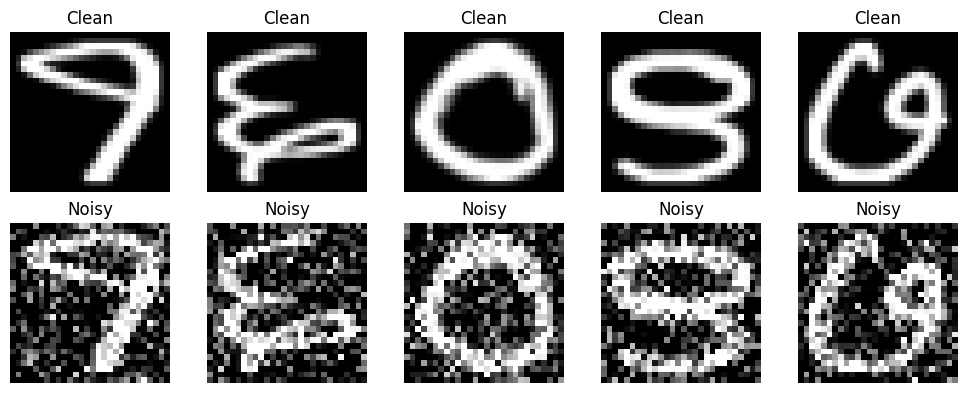

In [15]:
def show_noisy_samples(clean, noisy, n=5):
    plt.figure(figsize=(10, 4))
    for i in range(n):
        plt.subplot(2, n, i + 1)
        plt.imshow(clean[i].squeeze(), cmap='gray')
        plt.title('Clean')
        plt.axis('off')

        plt.subplot(2, n, i + 1 + n)
        plt.imshow(noisy[i].squeeze(), cmap='gray')
        plt.title('Noisy')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_noisy_samples(X_train, X_train_noisy, n=5)


## 7. Build the denoising convolutional autoencoder

In [16]:
def build_denoising_autoencoder(input_shape=(28, 28, 1)):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)

    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)

    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)

    # Decoder
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)

    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    outputs = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

    model = models.Model(inputs, outputs, name='denoising_autoencoder')
    model.compile(optimizer='adam', loss='binary_crossentropy')
    return model

autoencoder = build_denoising_autoencoder()
autoencoder.summary()


Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 480,385 (1.83 MB)

 Trainable params: 480,385 (1.83 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Train the model

In [17]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = autoencoder.fit(
    X_train_noisy, X_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(X_val_noisy, X_val),
    callbacks=[early_stop]
)


Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 176s 1s/step - loss: 0.2954 - val_loss: 0.1908
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - loss: 0.1826 - val_loss: 0.1761
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 162s 1s/step - loss: 0.1746 - val_loss: 0.1728
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 199s 1s/step - loss: 0.1703 - val_loss: 0.1709
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step - loss: 0.1679 - val_loss: 0.1669
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - loss: 0.1661 - val_loss: 0.1654
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - loss: 0.1651 - val_loss: 0.1675
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - loss: 0.1640 - val_loss: 0.1636
Epoch 9/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step - loss: 0.1631 - val_loss: 0.1628
Epoch 10/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - loss: 0.1625 - val_loss: 0.1623
Epoch 11/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - loss: 0.1616 - val_loss: 0.1623
Epoch 12/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 

## 9. Plot loss curves

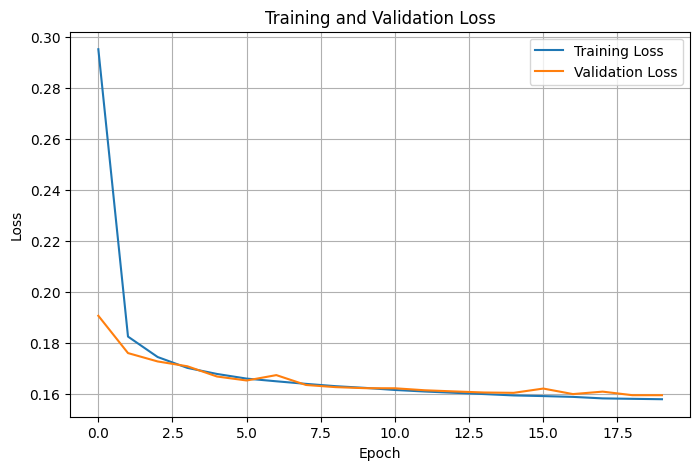

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


## 10. Denoise validation images

In [19]:
denoised_images = autoencoder.predict(X_val_noisy)


125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 85ms/step


## 11. Visualize noisy, denoised, and clean images

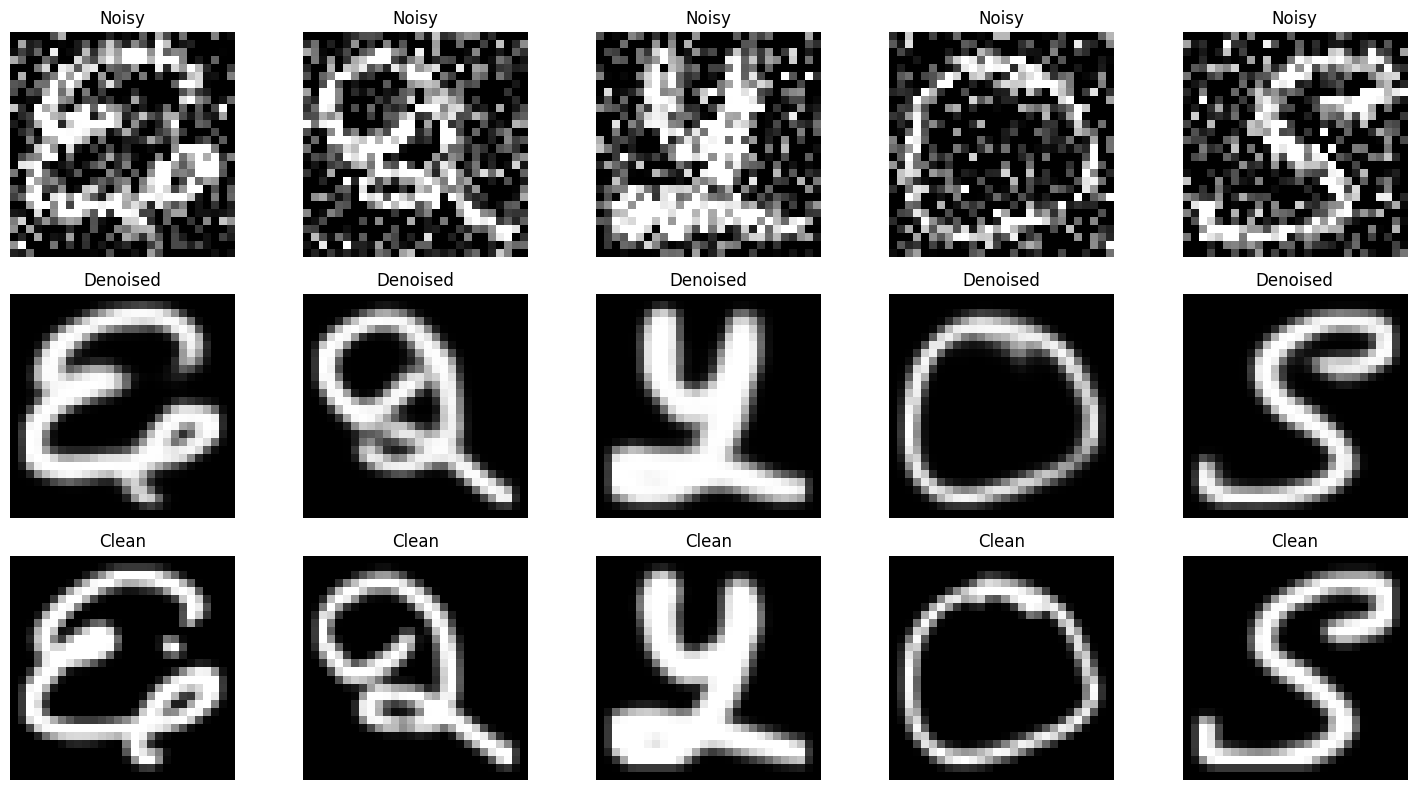

In [20]:
def plot_results(noisy_images, denoised_images, clean_images, n=5):
    plt.figure(figsize=(15, 8))
    for i in range(n):
        plt.subplot(3, n, i + 1)
        plt.imshow(noisy_images[i].squeeze(), cmap='gray')
        plt.title('Noisy')
        plt.axis('off')

        plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised_images[i].squeeze(), cmap='gray')
        plt.title('Denoised')
        plt.axis('off')

        plt.subplot(3, n, i + 1 + 2*n)
        plt.imshow(clean_images[i].squeeze(), cmap='gray')
        plt.title('Clean')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_results(X_val_noisy, denoised_images, X_val, n=5)


## 12. Save the model

In [21]:
autoencoder.save('/content/devnagari_denoising_autoencoder.h5')
print('Model saved successfully.')


Model saved successfully.
